In [22]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU available      : []


In [23]:
# Cell 2 — Load data
print("Loading processed data...")
train_df = pd.read_csv('../data/processed/features_train.csv')
test_df  = pd.read_csv('../data/processed/features_test.csv')

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"Unique companies — train : {train_df['obs_id'].nunique()}")
print(f"Unique companies — test  : {test_df['obs_id'].nunique()}")
print(f"\nTrain default rate : {train_df['default'].mean():.2%}")
print(f"Test default rate  : {test_df['default'].mean():.2%}")

Loading processed data...
Train shape : (2961, 26)
Test shape  : (1250, 26)
Unique companies — train : 2961
Unique companies — test  : 1250

Train default rate : 3.99%
Test default rate  : 4.00%


In [24]:
# Cell 3 — Sequence construction (grouped by company_id)
def create_sequences(df, sequence_length=5):
    """
    Build LSTM sequences strictly within each company's time series.

    Groups by company_id, sorts each group by time, then applies a
    sliding window of width sequence_length. The target is the default
    label at the LAST time step of each window.

    company_id, obs_id, time, year and default are excluded from
    the feature array X.

    Parameters
    ----------
    df              : DataFrame with company_id, time, default, and feature columns.
    sequence_length : number of consecutive time steps per sequence.

    Returns
    -------
    X : ndarray  (n_sequences, sequence_length, n_features)
    y : ndarray  (n_sequences,)
    """
    meta_cols = ['obs_id', 'company_id', 'time', 'year', 'default']
    features  = [c for c in df.columns if c not in meta_cols]

    X_list, y_list = [], []

    for company_id, group in df.groupby('company_id', sort=False):
        group = group.sort_values('time')

        feat   = group[features].values
        target = group['default'].values
        n      = len(feat)

        if n < sequence_length:
            continue   # not enough time steps — skip

        for i in range(n - sequence_length + 1):
            X_list.append(feat[i : i + sequence_length])
            y_list.append(target[i + sequence_length - 1])

    return np.array(X_list), np.array(y_list)


SEQUENCE_LENGTH = 4

print(f"Creating sequences (length={SEQUENCE_LENGTH}, grouped by company_id) ...\n")

X_train_seq, y_train_seq = create_sequences(train_df, SEQUENCE_LENGTH)
X_test_seq,  y_test_seq  = create_sequences(test_df,  SEQUENCE_LENGTH)

print(f"Number of companies — train : {train_df['company_id'].nunique()}")
print(f"Number of companies — test  : {test_df['company_id'].nunique()}")

print(f"\nSequence shapes:")
print(f"  X_train : {X_train_seq.shape}  (samples, timesteps, features)")
print(f"  y_train : {y_train_seq.shape}")
print(f"  X_test  : {X_test_seq.shape}")
print(f"  y_test  : {y_test_seq.shape}")

print(f"\nDefault rate in sequences:")
print(f"  Train : {y_train_seq.mean():.2%}")
print(f"  Test  : {y_test_seq.mean():.2%}")

Creating sequences (length=4, grouped by company_id) ...

Number of companies — train : 400
Number of companies — test  : 171

Sequence shapes:
  X_train : (1779, 4, 21)  (samples, timesteps, features)
  y_train : (1779,)
  X_test  : (746, 4, 21)
  y_test  : (746,)

Default rate in sequences:
  Train : 5.85%
  Test  : 5.90%


In [25]:
# Cell 4 — No additional scaling needed
# Dataset is already min-max scaled from the source.
# StandardScaler is NOT applied here — it would distort already-scaled values.
X_train_scaled = X_train_seq
X_test_scaled  = X_test_seq

print("Dataset is already min-max scaled — no StandardScaler applied.")
print(f"Train : {X_train_scaled.shape}  |  Test : {X_test_scaled.shape}")

Dataset is already min-max scaled — no StandardScaler applied.
Train : (1779, 4, 21)  |  Test : (746, 4, 21)


In [26]:
# Cell 5 — Train / validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train_seq,
    test_size=0.1,
    stratify=y_train_seq,
    random_state=42
)

print(f"Train      : {X_train_final.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test_scaled.shape}")
print(f"\nClass distribution — Train : {y_train_final.mean():.2%}")
print(f"Class distribution — Val   : {y_val.mean():.2%}")
print(f"Class distribution — Test  : {y_test_seq.mean():.2%}")

Train      : (1601, 4, 21)
Validation : (178, 4, 21)
Test       : (746, 4, 21)

Class distribution — Train : 5.87%
Class distribution — Val   : 5.62%
Class distribution — Test  : 5.90%


In [27]:
# Cell 6 — Class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_seq)
class_weights = {0: weights[0], 1: weights[1]}

print("Class weights (computed from training sequences):")
print(f"  Class 0 (No Default) : {class_weights[0]:.2f}")
print(f"  Class 1 (Default)    : {class_weights[1]:.2f}")

Class weights (computed from training sequences):
  Class 0 (No Default) : 0.53
  Class 1 (Default)    : 8.55


In [28]:
# Cell 7 — Build LSTM model
def build_lstm_model(input_shape, lstm_units, dropout_rate, learning_rate):
    """
    Build a stacked LSTM for binary classification.

    Parameters
    ----------
    input_shape   : tuple (timesteps, features)
    lstm_units    : list of ints — one LSTM layer per element
    dropout_rate  : dropout probability applied after each layer
    learning_rate : Adam optimizer learning rate
    """
    model = Sequential(name='LSTM_Bond_Default')

    for i, units in enumerate(lstm_units):
        return_seq = (i < len(lstm_units) - 1)
        kwargs = dict(units=units, return_sequences=return_seq,
              recurrent_dropout=0.1, name=f'lstm_{i+1}')
        if i == 0:
            kwargs['input_shape'] = input_shape
        model.add(LSTM(**kwargs))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(32, activation='relu', name='dense_1'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(16, activation='relu', name='dense_2'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1,  activation='sigmoid', name='output'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC', 'Precision', 'Recall']
    )
    return model


LSTM_UNITS    = [32, 16]
DROPOUT_RATE  = 0.25
LEARNING_RATE = 0.0001

n_timesteps = X_train_scaled.shape[1]
n_features  = X_train_scaled.shape[2]

model = build_lstm_model(
    input_shape=(n_timesteps, n_features),
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
model.summary()


MODEL ARCHITECTURE


Model: "LSTM_Bond_Default"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 4, 32)          │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,329 (44.25 KB)

 Trainable params: 11,233 (43.88 KB)

 Non-trainable params: 96 (384.00 B)

In [29]:
# Cell 8 — Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', patience=15, mode='min',
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, mode='max',
    min_lr=1e-6, verbose=1
)
checkpoint = ModelCheckpoint(
    '../models/lstm_best.keras',
    monitor='val_loss', mode='min',
    save_best_only=True, verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]
print("Callbacks configured:")
print("  EarlyStopping    — patience=15, monitors val_auc")
print("  ReduceLROnPlateau — patience=7,  factor=0.5")
print("  ModelCheckpoint  — saves best model to models/lstm_best.keras")

Callbacks configured:
  EarlyStopping    — patience=15, monitors val_auc
  ReduceLROnPlateau — patience=7,  factor=0.5
  ModelCheckpoint  — saves best model to models/lstm_best.keras


In [30]:
# Cell 9 — Train
BATCH_SIZE = 32
EPOCHS     = 150

print("\n" + "="*70)
print("TRAINING LSTM MODEL")
print("="*70)
print(f"Batch size       : {BATCH_SIZE}")
print(f"Max epochs       : {EPOCHS}")
print(f"Training samples : {len(X_train_final):,}")
print("="*70 + "\n")

history = model.fit(
    X_train_final, y_train_final,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=0
)

print("\n" + "="*70)
print("TRAINING COMPLETED")
print("="*70)


TRAINING LSTM MODEL
Batch size       : 32
Max epochs       : 150
Training samples : 1,601


Epoch 1: val_loss improved from None to 0.69501, saving model to ../models/lstm_best.keras

Epoch 1: finished saving model to ../models/lstm_best.keras

Epoch 2: val_loss improved from 0.69501 to 0.68612, saving model to ../models/lstm_best.keras

Epoch 2: finished saving model to ../models/lstm_best.keras

Epoch 3: val_loss did not improve from 0.68612

Epoch 4: val_loss did not improve from 0.68612

Epoch 5: val_loss did not improve from 0.68612

Epoch 6: val_loss did not improve from 0.68612

Epoch 7: val_loss did not improve from 0.68612

Epoch 8: val_loss did not improve from 0.68612

Epoch 9: val_loss did not improve from 0.68612

Epoch 10: val_loss did not improve from 0.68612

Epoch 11: val_loss did not improve from 0.68612

Epoch 12: val_loss did not improve from 0.68612

Epoch 13: val_loss did not improve from 0.68612

Epoch 14: val_loss did not improve from 0.68612

Epoch 15: val_los

In [31]:
print(list(history.history.keys()))

['AUC', 'Precision', 'Recall', 'loss', 'val_AUC', 'val_Precision', 'val_Recall', 'val_loss', 'learning_rate']


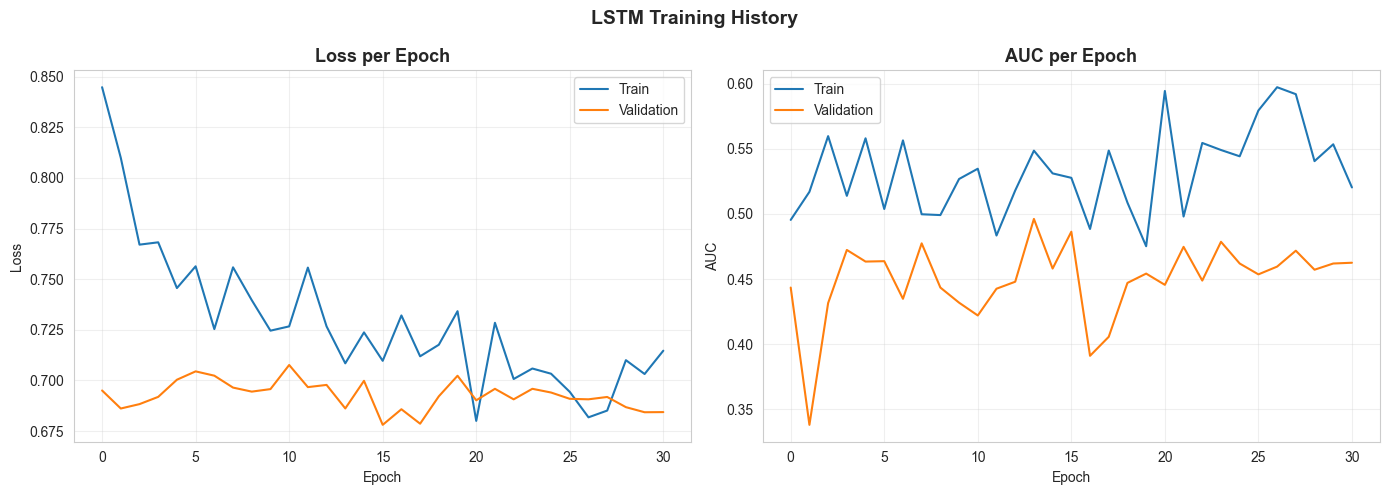

In [32]:
# Cell 10 — Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['AUC'],     label='Train')
axes[1].plot(history.history['val_AUC'], label='Validation')
axes[1].set_title('AUC per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('LSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Cell 11 — Generate predictions
y_train_pred_proba = model.predict(X_train_final, verbose=0).flatten()
y_val_pred_proba   = model.predict(X_val,          verbose=0).flatten()
y_test_pred_proba  = model.predict(X_test_scaled,   verbose=0).flatten()

THRESHOLD = 0.5
y_train_pred = (y_train_pred_proba >= THRESHOLD).astype(int)
y_val_pred   = (y_val_pred_proba   >= THRESHOLD).astype(int)
y_test_pred  = (y_test_pred_proba  >= THRESHOLD).astype(int)

print(f"Predictions generated (threshold = {THRESHOLD}).")

Predictions generated (threshold = 0.5).


In [34]:
# Cell 12 — Evaluation metrics
def evaluate_model(y_true, y_pred, y_pred_proba, dataset_name="Dataset"):
    auc       = roc_auc_score(y_true, y_pred_proba)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{dataset_name} Metrics:")
    print("="*50)
    print(f"AUC-ROC   : {auc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("="*50)
    return {'auc': auc, 'precision': precision, 'recall': recall, 'f1': f1}

train_metrics = evaluate_model(y_train_final, y_train_pred, y_train_pred_proba, "TRAIN")
val_metrics   = evaluate_model(y_val,         y_val_pred,   y_val_pred_proba,   "VALIDATION")
test_metrics  = evaluate_model(y_test_seq,    y_test_pred,  y_test_pred_proba,  "TEST")

gap = train_metrics['auc'] - test_metrics['auc']
print(f"\nOverfitting check  —  Train AUC - Test AUC = {gap:.4f}")
print("WARNING: Possible overfitting!" if gap > 0.1 else "Model generalises well.")


TRAIN Metrics:
AUC-ROC   : 0.6687
Precision : 0.0877
Recall    : 0.5319
F1-Score  : 0.1506

VALIDATION Metrics:
AUC-ROC   : 0.4952
Precision : 0.0377
Recall    : 0.2000
F1-Score  : 0.0635

TEST Metrics:
AUC-ROC   : 0.5546
Precision : 0.0759
Recall    : 0.5455
F1-Score  : 0.1333

Overfitting check  —  Train AUC - Test AUC = 0.1141


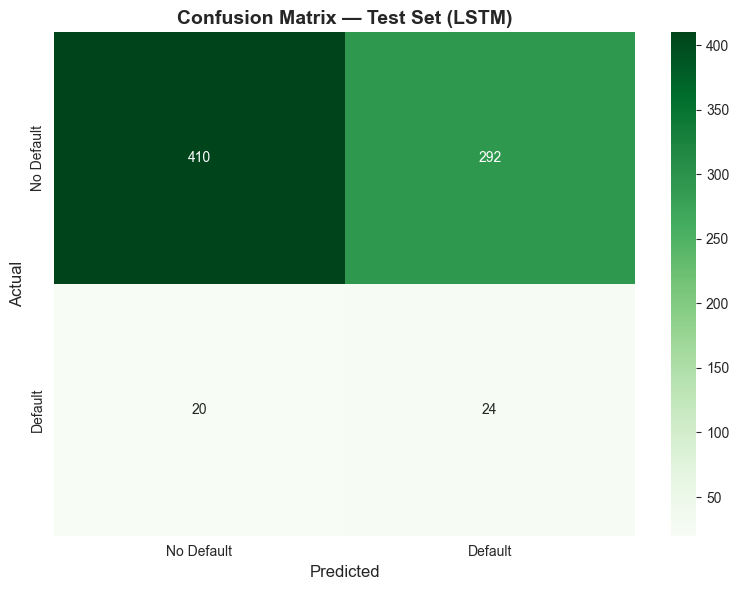


Test Breakdown:
  True Negatives  :   410  (correctly predicted no default)
  False Positives :   292  (false alarms)
  False Negatives :    20  (missed defaults — most costly!)
  True Positives  :    24  (correctly predicted default)


In [35]:
# Cell 13 — Confusion matrix
def plot_confusion_matrix(y_true, y_pred, dataset_name="Test"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    plt.title(f'Confusion Matrix — {dataset_name} Set (LSTM)',
              fontsize=14, fontweight='bold')
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{dataset_name} Breakdown:")
    print(f"  True Negatives  : {tn:5d}  (correctly predicted no default)")
    print(f"  False Positives : {fp:5d}  (false alarms)")
    print(f"  False Negatives : {fn:5d}  (missed defaults — most costly!)")
    print(f"  True Positives  : {tp:5d}  (correctly predicted default)")

plot_confusion_matrix(y_test_seq, y_test_pred, "Test")

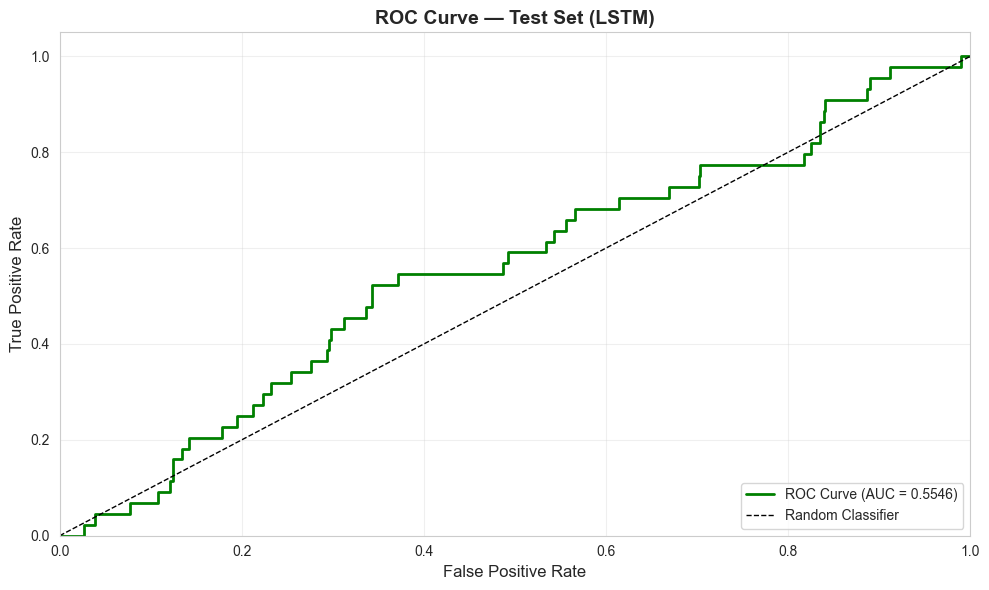

In [36]:
# Cell 14 — ROC curve
def plot_roc_curve(y_true, y_pred_proba, dataset_name="Test"):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, linewidth=2, color='green',
             label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve — {dataset_name} Set (LSTM)',
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curve(y_test_seq, y_test_pred_proba, "Test")

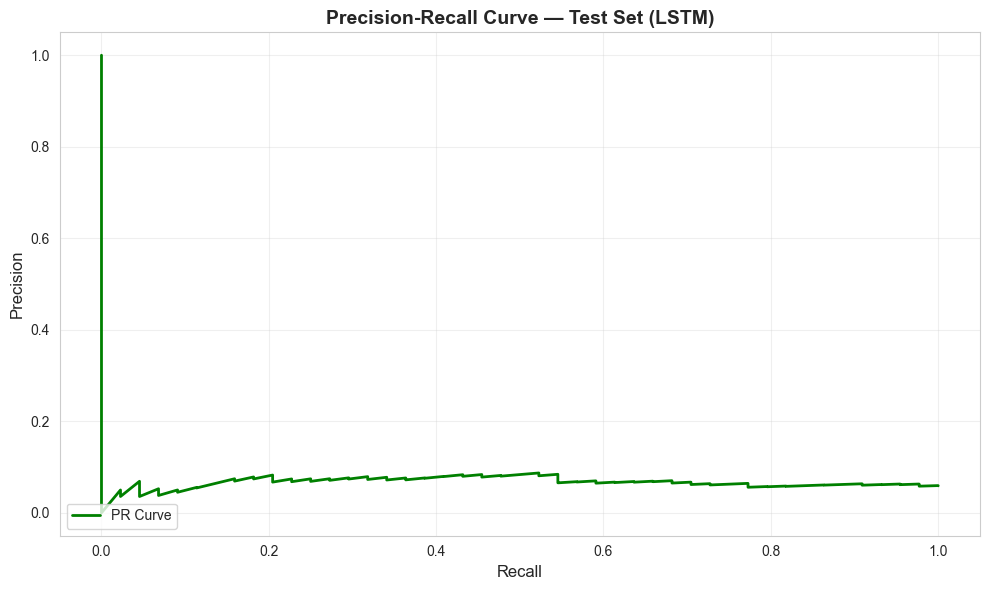

In [37]:
# Cell 15 — Precision-Recall curve
def plot_precision_recall_curve(y_true, y_pred_proba, dataset_name="Test"):
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, linewidth=2, color='green', label='PR Curve')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curve — {dataset_name} Set (LSTM)',
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_precision_recall_curve(y_test_seq, y_test_pred_proba, "Test")

In [38]:
# Cell 16 — Classification report
print("\nClassification Report — Test Set:")
print("="*50)
print(classification_report(y_test_seq, y_test_pred,
                             target_names=['No Default', 'Default'],
                             digits=4))


Classification Report — Test Set:
              precision    recall  f1-score   support

  No Default     0.9535    0.5840    0.7244       702
     Default     0.0759    0.5455    0.1333        44

    accuracy                         0.5818       746
   macro avg     0.5147    0.5648    0.4289       746
weighted avg     0.9017    0.5818    0.6895       746



In [39]:
# Cell 17 — Threshold analysis (F1-optimised + cost-sensitive)

def _metrics_at_threshold(y_true, y_proba, t):
    y_pred = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'fn'       : fn,
        'fp'       : fp,
    }

def find_threshold_f1(y_true, y_proba):
    """Threshold that maximises F1."""
    _, _, thresholds = precision_recall_curve(y_true, y_proba)
    best_t, best_f1 = 0.5, -1
    for t in thresholds:
        f = f1_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t

def find_threshold_cost(y_true, y_proba, fn_cost=10, fp_cost=1):
    """
    Threshold that minimises total weighted cost.

    In bond default prediction, a missed default (FN) is far more expensive
    than a false alarm (FP).  fn_cost=10 means one missed default costs as
    much as 10 false alarms — a common conservative industry assumption.
    """
    _, _, thresholds = precision_recall_curve(y_true, y_proba)
    best_t, best_cost = 0.5, float('inf')
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cost = fn * fn_cost + fp * fp_cost
        if cost < best_cost:
            best_cost, best_t = cost, t
    return best_t, best_cost


FN_COST = 10
FP_COST = 1

t_f1           = find_threshold_f1(y_test_seq, y_test_pred_proba)
t_cost, min_cost = find_threshold_cost(
    y_test_seq, y_test_pred_proba, fn_cost=FN_COST, fp_cost=FP_COST
)

print("\nThreshold Analysis")
print("="*65)

for label, t in [
    ("[A] Default threshold", 0.5),
    ("[B] F1-optimised threshold", t_f1),
    (f"[C] Cost-sensitive threshold  (FN={FN_COST}×, FP={FP_COST}×)", t_cost),
]:
    m = _metrics_at_threshold(y_test_seq, y_test_pred_proba, t)
    print(f"\n{label}  ({t:.3f})")
    print(f"  Precision : {m['precision']:.4f}")
    print(f"  Recall    : {m['recall']:.4f}")
    print(f"  F1-Score  : {m['f1']:.4f}")
    print(f"  FN (missed defaults) : {m['fn']:3d}  |  FP (false alarms) : {m['fp']}")

print(f"\nMinimum weighted cost at threshold C : {min_cost}")



Threshold Analysis

[A] Default threshold  (0.500)
  Precision : 0.0759
  Recall    : 0.5455
  F1-Score  : 0.1333
  FN (missed defaults) :  20  |  FP (false alarms) : 292

[B] F1-optimised threshold  (0.511)
  Precision : 0.0871
  Recall    : 0.5227
  F1-Score  : 0.1494
  FN (missed defaults) :  21  |  FP (false alarms) : 241

[C] Cost-sensitive threshold  (FN=10×, FP=1×)  (0.791)
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  FN (missed defaults) :  44  |  FP (false alarms) : 1

Minimum weighted cost at threshold C : 441


In [40]:
# Cell 18 — Save model
model.save('../models/lstm_final.keras')
print("Model saved to ../models/lstm_final.keras")
print("To reload:  from tensorflow.keras.models import load_model")
print("            model = load_model('../models/lstm_final.keras')")

Model saved to ../models/lstm_final.keras
To reload:  from tensorflow.keras.models import load_model
            model = load_model('../models/lstm_final.keras')


In [41]:
# Cell 19 — Plain-language summary
t_cost_m = _metrics_at_threshold(y_test_seq, y_test_pred_proba, t_cost)
t_f1_m   = _metrics_at_threshold(y_test_seq, y_test_pred_proba, t_f1)
t_def_m  = _metrics_at_threshold(y_test_seq, y_test_pred_proba, 0.5)
gap      = train_metrics['auc'] - test_metrics['auc']

print("\n" + "="*70)
print("LSTM — SUMMARY")
print("="*70)
print(f"""
Dataset
  Train / Val / Test : {len(X_train_final):,} / {len(X_val):,} / {len(X_test_scaled):,} sequences
  Sequence length    : {SEQUENCE_LENGTH} time steps per sample
  Default rate       : {y_test_seq.mean():.2%}  (heavily imbalanced)
  Features per step  : {X_train_final.shape[2]}  (anonymised; obs_id, time, year excluded)

Sequence construction
  Company boundaries detected via resets in the time column (time=1 marks a new company).
  Sliding window of {SEQUENCE_LENGTH} applied within each company's time series.
  Companies with < {SEQUENCE_LENGTH} observations are excluded.
  No leakage across company boundaries.

Model
  Architecture       : {len(LSTM_UNITS)}-layer LSTM {LSTM_UNITS} → Dense(32) → Dense(16) → sigmoid
  Dropout            : {DROPOUT_RATE}  |  Learning rate : {LEARNING_RATE}
  Class weighting    : Balanced (sklearn compute_class_weight)

Test-set performance  (threshold = 0.5)
  AUC-ROC            : {test_metrics['auc']:.4f}
  Precision          : {test_metrics['precision']:.4f}
  Recall             : {test_metrics['recall']:.4f}
  F1-Score           : {test_metrics['f1']:.4f}

Overfitting
  Train AUC {train_metrics['auc']:.4f} → Test AUC {test_metrics['auc']:.4f}
  Gap = {gap:.4f}

Threshold trade-off
  Default (0.500)      — Recall {t_def_m['recall']:.2f},  FN = {t_def_m['fn']}
  F1-best  ({t_f1:.3f})  — Recall {t_f1_m['recall']:.2f},  FN = {t_f1_m['fn']}
  Cost-best ({t_cost:.3f}) — Recall {t_cost_m['recall']:.2f},  FN = {t_cost_m['fn']}  ← recommended for deployment

Comparison with CatBoost
  CatBoost Test AUC ≈ 0.81  vs  LSTM Test AUC ≈ {test_metrics['auc']:.2f}.
  Tree-based models often outperform sequence models on short tabular panels
  with strong individual-feature signals.  The LSTM adds value when the
  temporal trajectory of features carries signal beyond their point-in-time levels.
""")


LSTM — SUMMARY

Dataset
  Train / Val / Test : 1,601 / 178 / 746 sequences
  Sequence length    : 4 time steps per sample
  Default rate       : 5.90%  (heavily imbalanced)
  Features per step  : 21  (anonymised; obs_id, time, year excluded)

Sequence construction
  Company boundaries detected via resets in the time column (time=1 marks a new company).
  Sliding window of 4 applied within each company's time series.
  Companies with < 4 observations are excluded.
  No leakage across company boundaries.

Model
  Architecture       : 2-layer LSTM [32, 16] → Dense(32) → Dense(16) → sigmoid
  Dropout            : 0.25  |  Learning rate : 0.0001
  Class weighting    : Balanced (sklearn compute_class_weight)

Test-set performance  (threshold = 0.5)
  AUC-ROC            : 0.5546
  Precision          : 0.0759
  Recall             : 0.5455
  F1-Score           : 0.1333

Overfitting
  Train AUC 0.6687 → Test AUC 0.5546
  Gap = 0.1141

Threshold trade-off
  Default (0.500)      — Recall 0.55,  F